### Second-Order Differential Equation

$
m\ddot{y} + c\dot{y} + ky = 0
$

where:
- $ m $ is the mass,
- $ c $ is the damping coefficient,
- $ k $ is the spring stiffness.

### First-Order System (State-Space Form)

$
\begin{cases}
\frac{dy}{dt} = v \\
\frac{dv}{dt} = -\frac{c}{m}v - \frac{k}{m}y
\end{cases}
$

### Damping Ratio

$
\zeta = \frac{c}{2\sqrt{mk}}
$

- $\zeta < 1$: The system oscillates with gradually decreasing amplitude.
- $\zeta = 1$: The system returns to equilibrium as quickly as possible without oscillating.
- $\zeta > 1$: The system returns to equilibrium without oscillations but slower compared to the critically damped case.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System parameters
m = 1.0      # Mass (kg)
k = 20.0     # Spring stiffness (N/m)

# Damping coefficients for no damping, underdamped, critically damped, and overdamped
c_values = {
    r'$\zeta = 0$': 0.0,
    r'$\zeta < 1$': 1.0,
    r'$\zeta = 1$': 2 * np.sqrt(m * k),
    r'$\zeta > 1$': 20.0
}

# Initial condition
y0, v0 = 1.0, 0.0

# Define the system of first-order differential equations
def damped_oscillator(t, yv, c):
    y, v = yv
    dydt = v
    dvdt = -(c/m)*v - (k/m)*y
    return [dydt, dvdt]

# Time span and evaluation points
t_span = (0, 10)
t_eval = np.linspace(*t_span, 1000)

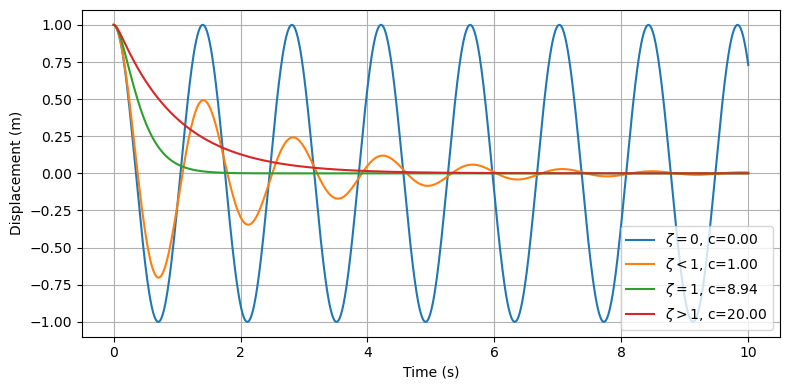

In [2]:
# Plot time response for different damping ratios
plt.figure(figsize=(8, 4))

for label, c in c_values.items():
    sol = solve_ivp(damped_oscillator, t_span, [y0, v0], t_eval=t_eval, args=(c,))
    plt.plot(sol.t, sol.y[0], label=f'{label}, c={c:.2f}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

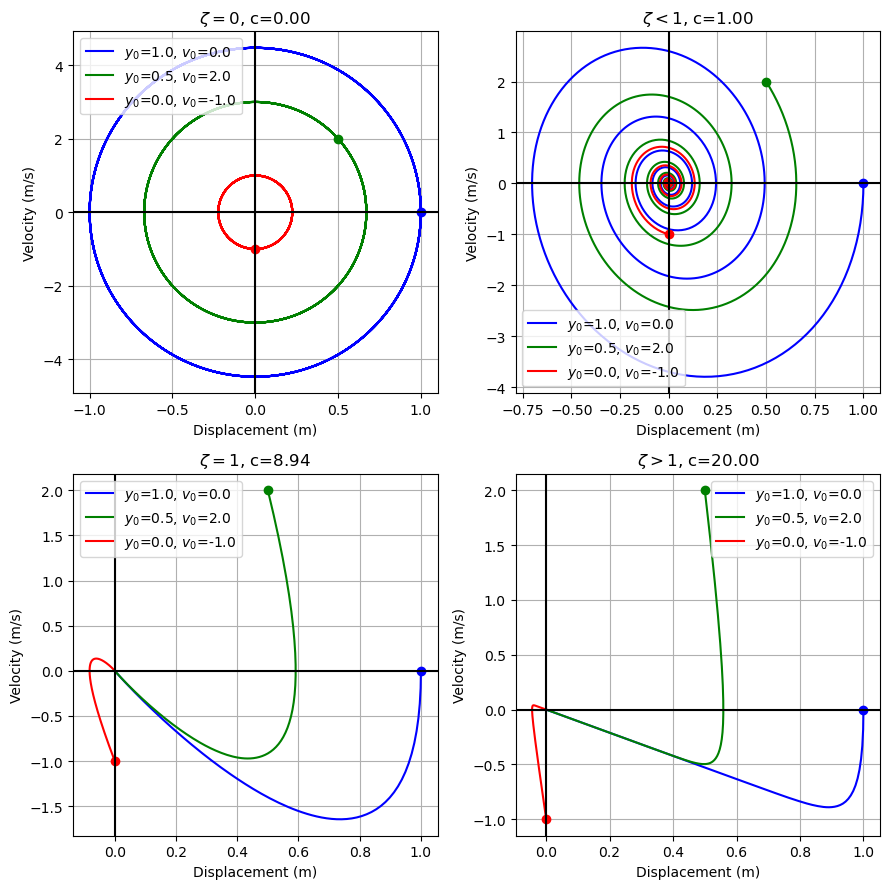

In [3]:
initial_conditions = [(1.0, 0.0), (0.5, 2.0), (0.0, -1.0)]
colors = ['b', 'g', 'r']

# Plot phase diagram (velocity vs displacement)
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()

for i, (label, c) in enumerate(c_values.items()):
    ax = axs[i]
    for j, (y0, v0) in enumerate(initial_conditions):
        sol = solve_ivp(damped_oscillator, t_span, [y0, v0], t_eval=t_eval, args=(c,))
        y_vals = sol.y[0]
        v_vals = sol.y[1]
        ax.plot(y_vals, v_vals, label=f'$y_0$={y0}, $v_0$={v0}', color=colors[j])
        ax.plot(y_vals[0], v_vals[0], 'o', color=colors[j])
    ax.set_title(f'{label}, c={c:.2f}')
    ax.set_xlabel('Displacement (m)')
    ax.set_ylabel('Velocity (m/s)')
    ax.axhline(0, color='k')
    ax.axvline(0, color='k')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()